<!-- codex-architecture-notes -->
## Architectural Notes

**Purpose:** Cleans raw student-course attempt records into the core course-outcome table.

**Notebook Shape:** 63 cells (53 code, 10 markdown).

**Inputs / Data Sources:**
- `df_raw = pd.read_parquet(data_path)`
- `df_raw = pd.read_csv(data_path, dtype="string")`

**Outputs / Side Effects:**
- `clean_student_course_attempts.to_parquet(r"D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\clean_v_crg_student_course.parquet", index=False)`

**Logic Flow:**
1. Load raw CRG student-course data.
2. Normalize IDs and numeric fields.
3. Diagnose marks, statuses, and duplicates.
4. Write cleaned course-attempt parquet.

**Maintainability Notes:** This table supplies targets and course attempts; mark/status cleaning rules should be versioned and regression-tested.


# V_CRG_STUDENT_COURSE — Cleaning Notebook

This notebook cleans the student course attempts table from `V_CRG_STUDENT_COURSE`.

The output table is `clean_student_course_attempts`.

The table grain is one row per `student_course_id`.

`clean_student_course_attempts` represents completed course attempts with real pass/fail academic outcomes.

Withdrawn courses are excluded from this clean table and stored in `audit_removed_withdrawn`.

Withdrawn history can be modeled later in a separate feature table if needed.

It is not a course-offer table and not an eligibility table.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from src.id_casting import normalize_ids
from src.schemas import TABLE_CRG_STUDENT_COURSE

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

In [2]:
VERSION = "v1"

# Fill DATA_PATH manually with the source .parquet or .csv file path before running the loading cell.
from src.paths import RAW_DIR, PREPROCESSED_DIR, assert_data_root
from src.io_utils import save_parquet
DATA_PATH = RAW_DIR / "v_crg_student_course_raw.parquet"

# Data-root guard (governance contract 12).
assert_data_root(DATA_PATH)

In [3]:
if not DATA_PATH:
    raise ValueError("DATA_PATH is empty. Fill DATA_PATH manually with the source .parquet or .csv file path before running this cell.")

data_path = Path(DATA_PATH)
suffix = data_path.suffix.lower()

if suffix == ".parquet":
    df_raw = pd.read_parquet(data_path)
elif suffix == ".csv":
    df_raw = pd.read_csv(data_path, dtype="string")
else:
    raise ValueError("DATA_PATH must point to a .parquet or .csv file.")

## Initial Inspection

In [4]:
df_raw.shape

(1017491, 20)

In [5]:
df_raw.columns.tolist()

['student_course_id',
 'student_id',
 'course_id',
 'part_id',
 'grade_id',
 'final_mark',
 'points',
 'finish_status',
 'course_name_sl',
 'register_status',
 'in_credits',
 'in_gpa',
 'in_agpa',
 'study_mode',
 'degree_id',
 'student_name_sl',
 'degree_name_sl',
 'faculty_id',
 'course_credits',
 'active']

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017491 entries, 0 to 1017490
Data columns (total 20 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   student_course_id  1017491 non-null  float64
 1   student_id         1017491 non-null  float64
 2   course_id          1017490 non-null  float64
 3   part_id            1017490 non-null  float64
 4   grade_id           885366 non-null   float64
 5   final_mark         884956 non-null   float64
 6   points             885366 non-null   float64
 7   finish_status      885365 non-null   str    
 8   course_name_sl     1017490 non-null  str    
 9   register_status    1017491 non-null  str    
 10  in_credits         1017403 non-null  str    
 11  in_gpa             1017415 non-null  str    
 12  in_agpa            1017415 non-null  str    
 13  study_mode         1017491 non-null  str    
 14  degree_id          1017457 non-null  float64
 15  student_name_sl    1017491 non-null  str   

In [7]:
df_raw.head(5)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
0,430311.111,2117.111,962.111,20132.0,679.111,70.0,2.50,P,اللغة الانكليزية 2,R,Y,Y,Y,C,13.111,محمد نبيل حلواني,الصيدلة و الكيمياء الصيدلية,4.111,2.0,A
1,430312.111,2117.111,966.111,20132.0,680.111,68.0,2.25,P,كيمياء عضوية صيدلانية 1,R,Y,Y,Y,C,13.111,محمد نبيل حلواني,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
2,430313.111,2117.111,967.111,20132.0,680.111,69.0,2.25,P,مهارات الحاسوب,R,Y,Y,Y,C,13.111,محمد نبيل حلواني,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
3,430314.111,2117.111,963.111,20132.0,684.111,48.0,0.00,F,بيولوجيا نباتية,R,Y,Y,Y,C,13.111,محمد نبيل حلواني,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
4,430315.111,2117.111,964.111,20132.0,679.111,70.0,2.50,P,إحصاء حيوي,R,Y,Y,Y,C,13.111,محمد نبيل حلواني,الصيدلة و الكيمياء الصيدلية,4.111,2.0,A


In [8]:
null_report = (
    df_raw.isna()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(null_rate=lambda x: x["null_count"] / len(df_raw))
    .sort_values("null_count", ascending=False)
)

null_report

,null_count,null_rate
final_mark,132535,1.302567e-01
finish_status,132126,1.298547e-01
points,132125,1.298537e-01
grade_id,132125,1.298537e-01
in_credits,88,8.648725e-05
in_gpa,76,7.469354e-05
in_agpa,76,7.469354e-05
degree_id,34,3.341553e-05
faculty_id,34,3.341553e-05
degree_name_sl,34,3.341553e-05


In [9]:
nunique_report = (
    df_raw.nunique(dropna=False)
    .rename("nunique_including_null")
    .to_frame()
    .sort_values("nunique_including_null", ascending=False)
)

nunique_report

,nunique_including_null
student_course_id,1017491
student_id,16910
student_name_sl,16739
course_id,1159
course_name_sl,959
final_mark,102
part_id,68
grade_id,61
degree_id,53
degree_name_sl,51


In [10]:
df_raw["register_status"].value_counts(dropna=False)

register_status
R    853008
D    104655
T     21998
E     14669
Y     10864
X      5292
L      4505
M      2194
O       247
P        41
N        18
Name: count, dtype: int64

In [11]:
df_raw["finish_status"].value_counts(dropna=False)

finish_status
P      680834
NaN    132126
F      104586
W       40127
T       21998
Z       15087
ST      13390
X        5292
D        2042
FA       1143
FE        611
IP        121
L         108
I          26
Name: count, dtype: int64

In [12]:
df_raw["active"].value_counts(dropna=False)

active
A    1017491
Name: count, dtype: int64

## Helper Functions

In [13]:
def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with lowercase snake_case column names."""
    normalized_columns = (
        pd.Index(df.columns)
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)
        .str.strip("_")
        .str.lower()
    )
    return df.copy().set_axis(normalized_columns, axis=1)


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None: 
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")


def normalize_text_series(series: pd.Series) -> pd.Series:
    cleaned = series.astype("string").str.strip()
    return cleaned.mask(cleaned == "", pd.NA)


def normalize_code_series(series: pd.Series) -> pd.Series:
    return normalize_text_series(series).str.upper()


def convert_nullable_integer(series: pd.Series, column_name: str) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    source_has_value = series.notna() & (series.astype("string").str.strip() != "")
    invalid_values = source_has_value & numeric.isna()

    if invalid_values.any():
        examples = series.loc[invalid_values].drop_duplicates().head(10).tolist()
        raise ValueError(f"{column_name} contains non-numeric values that cannot be converted to Int64. Examples: {examples}")

    numeric_values = numeric.dropna()
    non_integer_values = numeric_values[~np.isclose(numeric_values % 1, 0, atol=1e-9)]

    if not non_integer_values.empty:
        examples = series.loc[non_integer_values.index].drop_duplicates().head(10).tolist()
        raise ValueError(f"{column_name} contains non-integer values that cannot be converted to Int64. Examples: {examples}")

    return numeric.round().astype("Int64")


def validate_final_mark_is_integer(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    source_has_value = series.notna() & (series.astype("string").str.strip() != "")
    invalid_values = source_has_value & numeric.isna()

    if invalid_values.any():
        examples = series.loc[invalid_values].drop_duplicates().head(10).tolist()
        raise ValueError(f"final_mark contains non-numeric values. Examples: {examples}")

    numeric_values = numeric.dropna()
    non_integer_values = numeric_values[~np.isclose(numeric_values % 1, 0, atol=1e-9)]

    if not non_integer_values.empty:
        examples = series.loc[non_integer_values.index].drop_duplicates().head(10).tolist()
        raise ValueError(f"final_mark contains non-integer decimals. Examples: {examples}")

    return numeric.round().astype("Int64")


def create_audit_summary(audit_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"audit_table": audit_name, "rows": len(audit_df), "columns": audit_df.shape[1]}
            for audit_name, audit_df in audit_frames.items()
        ]
    )

## Cleaning Function

In [14]:
EXPECTED_SOURCE_COLUMNS = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "final_mark",
    "points",
    "finish_status",
    "course_name_sl",
    "register_status",
    "in_credits",
    "in_gpa",
    "in_agpa",
    "study_mode",
    "degree_id",
    "student_name_sl",
    "degree_name_sl",
    "faculty_id",
    "course_credits",
    "active",
]

EXPECTED_CLEAN_COLUMNS = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "degree_id",
    "faculty_id",
    "grade_id",
    "final_mark",
    "points",
    "finish_status",
    "course_outcome_status",
    "register_status",
    "in_credits",
    "in_gpa",
    "in_agpa",
    "study_mode",
    "course_credits",
    "course_name_sl",
    "degree_name_sl",
    "attempt_number",
    "attempt_count",
]

VALID_REGISTER_STATUSES = {"R", "E"}
VALID_FINISH_STATUSES = {"P", "F", "FE", "FA"}
VALID_COURSE_OUTCOME_STATUSES = {"passed", "failed"}


def clean_v_crg_student_course(df_raw: pd.DataFrame) -> dict:
    df = normalize_column_names(df_raw)
    validate_required_columns(df, EXPECTED_SOURCE_COLUMNS)

    raw_rows = len(df)

    df["active"] = normalize_code_series(df["active"])
    active_mask = df["active"].eq("A")
    audit_removed_inactive = df.loc[~active_mask].copy()
    df_active = df.loc[active_mask].copy()
    rows_after_active_filter = len(df_active)

    df_active["register_status"] = normalize_code_series(df_active["register_status"])
    register_status_mask = df_active["register_status"].isin(VALID_REGISTER_STATUSES)
    audit_removed_register_status = df_active.loc[~register_status_mask].copy()
    df_registered = df_active.loc[register_status_mask].copy()
    rows_after_register_status_filter = len(df_registered)

    df_registered["finish_status"] = normalize_code_series(df_registered["finish_status"])
    withdrawn_mask = df_registered["finish_status"].eq("W").fillna(False)
    audit_removed_withdrawn = df_registered.loc[withdrawn_mask].copy()
    df_non_withdrawn = df_registered.loc[~withdrawn_mask].copy()

    finish_status_mask = df_non_withdrawn["finish_status"].isin(VALID_FINISH_STATUSES)
    audit_removed_finish_status = df_non_withdrawn.loc[~finish_status_mask].copy()
    df_finished = df_non_withdrawn.loc[finish_status_mask].copy()
    rows_after_finish_status_filter = len(df_finished)

    cleaned = df_finished.copy()

    # In-place ID casting per src/schemas.py: entity IDs -> string;
    # part_id (semester code) -> Int64. No _key duplicates.
    cleaned = normalize_ids(cleaned, table=TABLE_CRG_STUDENT_COURSE)
    cleaned["final_mark"] = validate_final_mark_is_integer(cleaned["final_mark"])
    cleaned["points"] = pd.to_numeric(cleaned["points"], errors="coerce").astype("Float64")
    cleaned["course_credits"] = pd.to_numeric(cleaned["course_credits"], errors="coerce").astype("Float64")

    for column in ["course_name_sl", "degree_name_sl"]:
        cleaned[column] = normalize_text_series(cleaned[column])

    for column in ["in_credits", "in_gpa", "in_agpa", "study_mode"]:
        cleaned[column] = normalize_code_series(cleaned[column])

    critical_columns = ["student_course_id", "student_id", "course_id", "part_id", "course_credits"]
    missing_critical_mask = cleaned[critical_columns].isna().any(axis=1)
    audit_removed_missing_critical = cleaned.loc[missing_critical_mask].copy()
    cleaned = cleaned.loc[~missing_critical_mask].copy()

    bad_course_credits_mask = cleaned["course_credits"].le(0)
    audit_removed_bad_course_credits = cleaned.loc[bad_course_credits_mask].copy()
    cleaned = cleaned.loc[~bad_course_credits_mask].copy()

    bad_final_mark_mask = cleaned["final_mark"].notna() & ~cleaned["final_mark"].between(0, 100)
    audit_removed_bad_final_mark = cleaned.loc[bad_final_mark_mask].copy()
    cleaned = cleaned.loc[~bad_final_mark_mask].copy()

    outcome_map = {
        "P": "passed",
        "F": "failed",
        "FE": "failed",
        "FA": "failed",
    }
    cleaned["course_outcome_status"] = cleaned["finish_status"].map(outcome_map).astype("string")

    cleaned = cleaned.sort_values(
        ["student_id", "course_id", "part_id", "student_course_id"],
        kind="mergesort",
    ).reset_index(drop=True)

    attempt_group = cleaned.groupby(["student_id", "course_id"], dropna=False, sort=False)
    cleaned["attempt_number"] = (attempt_group.cumcount() + 1).astype("Int64")
    cleaned["attempt_count"] = attempt_group["student_course_id"].transform("size").astype("Int64")

    for column in ["finish_status", "course_outcome_status", "register_status", "in_credits", "in_gpa", "in_agpa", "study_mode"]:
        cleaned[column] = cleaned[column].astype("category")

    clean_student_course_attempts = cleaned[EXPECTED_CLEAN_COLUMNS].copy()

    duplicate_student_course_id_count = int(clean_student_course_attempts["student_course_id"].duplicated().sum())
    duplicate_student_course_part_count = int(
        clean_student_course_attempts.duplicated(["student_id", "course_id", "part_id"]).sum()
    )
    null_final_mark_rows = int(clean_student_course_attempts["final_mark"].isna().sum())

    cleaning_summary = pd.DataFrame(
        [
            {
                "raw_rows": raw_rows,
                "rows_after_active_filter": rows_after_active_filter,
                "rows_after_register_status_filter": rows_after_register_status_filter,
                "rows_after_finish_status_filter": rows_after_finish_status_filter,
                "final_clean_rows": len(clean_student_course_attempts),
                "final_clean_rows_after_dropping_withdrawn": len(clean_student_course_attempts),
                "removed_inactive_rows": len(audit_removed_inactive),
                "removed_register_status_rows": len(audit_removed_register_status),
                "removed_withdrawn_rows": len(audit_removed_withdrawn),
                "removed_finish_status_rows": len(audit_removed_finish_status),
                "removed_missing_critical_rows": len(audit_removed_missing_critical),
                "removed_bad_course_credits_rows": len(audit_removed_bad_course_credits),
                "removed_bad_final_mark_rows": len(audit_removed_bad_final_mark),
                "unique_students": clean_student_course_attempts["student_id"].nunique(dropna=True),
                "unique_courses": clean_student_course_attempts["course_id"].nunique(dropna=True),
                "unique_semesters": clean_student_course_attempts["part_id"].nunique(dropna=True),
                "unique_degrees": clean_student_course_attempts["degree_id"].nunique(dropna=True),
                "duplicate_student_course_id_count": duplicate_student_course_id_count,
                "duplicate_student_course_part_count": duplicate_student_course_part_count,
                "null_final_mark_rows": null_final_mark_rows,
            }
        ]
    )

    if duplicate_student_course_id_count > 0:
        raise ValueError(f"student_course_id must be unique. Duplicate row count: {duplicate_student_course_id_count}")

    null_counts = clean_student_course_attempts[critical_columns].isna().sum()
    if null_counts.any():
        raise ValueError(f"Clean output contains nulls in critical columns: {null_counts[null_counts > 0].to_dict()}")

    actual_register_statuses = set(clean_student_course_attempts["register_status"].dropna().astype("string"))
    if not actual_register_statuses.issubset(VALID_REGISTER_STATUSES):
        raise ValueError(f"Unexpected register_status values: {sorted(actual_register_statuses - VALID_REGISTER_STATUSES)}")

    actual_finish_statuses = set(clean_student_course_attempts["finish_status"].dropna().astype("string"))
    if not actual_finish_statuses.issubset(VALID_FINISH_STATUSES):
        raise ValueError(f"Unexpected finish_status values: {sorted(actual_finish_statuses - VALID_FINISH_STATUSES)}")

    actual_outcome_statuses = set(clean_student_course_attempts["course_outcome_status"].dropna().astype("string"))
    if not actual_outcome_statuses.issubset(VALID_COURSE_OUTCOME_STATUSES):
        raise ValueError(f"Unexpected course_outcome_status values: {sorted(actual_outcome_statuses - VALID_COURSE_OUTCOME_STATUSES)}")

    validate_final_mark_is_integer(clean_student_course_attempts["final_mark"])

    out_of_range_final_mark_count = int(
        (clean_student_course_attempts["final_mark"].notna() & ~clean_student_course_attempts["final_mark"].between(0, 100)).sum()
    )
    if out_of_range_final_mark_count:
        raise ValueError(f"final_mark must be between 0 and 100 when not null. Bad row count: {out_of_range_final_mark_count}")

    if null_final_mark_rows:
        raise ValueError(
            "final_mark must not be null in clean_student_course_attempts after withdrawn rows are excluded. "
            f"Bad row count: {null_final_mark_rows}."
        )

    non_positive_course_credits_count = int(clean_student_course_attempts["course_credits"].le(0).sum())
    if non_positive_course_credits_count:
        raise ValueError(f"course_credits must be greater than 0. Bad row count: {non_positive_course_credits_count}")

    return {
        "clean_student_course_attempts": clean_student_course_attempts,
        "audit_removed_inactive": audit_removed_inactive,
        "audit_removed_register_status": audit_removed_register_status,
        "audit_removed_withdrawn": audit_removed_withdrawn,
        "audit_removed_finish_status": audit_removed_finish_status,
        "audit_removed_missing_critical": audit_removed_missing_critical,
        "audit_removed_bad_course_credits": audit_removed_bad_course_credits,
        "audit_removed_bad_final_mark": audit_removed_bad_final_mark,
        "cleaning_summary": cleaning_summary,
    }

## Run Cleaning

In [15]:
results = clean_v_crg_student_course(df_raw)

clean_student_course_attempts = results["clean_student_course_attempts"]
audit_removed_inactive = results["audit_removed_inactive"]
audit_removed_register_status = results["audit_removed_register_status"]
audit_removed_withdrawn = results["audit_removed_withdrawn"]
audit_removed_finish_status = results["audit_removed_finish_status"]
audit_removed_missing_critical = results["audit_removed_missing_critical"]
audit_removed_bad_course_credits = results["audit_removed_bad_course_credits"]
audit_removed_bad_final_mark = results["audit_removed_bad_final_mark"]
cleaning_summary = results["cleaning_summary"]

## Output Inspection

In [16]:
cleaning_summary

,raw_rows,rows_after_active_filter,rows_after_register_status_filter,rows_after_finish_status_filter,final_clean_rows,final_clean_rows_after_dropping_withdrawn,removed_inactive_rows,removed_register_status_rows,removed_withdrawn_rows,removed_finish_status_rows,removed_missing_critical_rows,removed_bad_course_credits_rows,removed_bad_final_mark_rows,unique_students,unique_courses,unique_semesters,unique_degrees,duplicate_student_course_id_count,duplicate_student_course_part_count,null_final_mark_rows
0,1017491,1017491,867677,786943,784299,784299,0,149814,40065,40669,1,2643,0,16179,1113,67,52,0,0,0


In [17]:
clean_student_course_attempts.shape

(784299, 21)

In [18]:
clean_student_course_attempts.head(20)

,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,points,finish_status,course_outcome_status,register_status,in_credits,in_gpa,in_agpa,study_mode,course_credits,course_name_sl,degree_name_sl,attempt_number,attempt_count
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,3.0,P,passed,R,Y,Y,Y,C,2.0,المنطق والتفكير العلمي,هندسة البرمجيات ونظم المعلومات,1,1
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.25,P,passed,R,Y,Y,Y,C,2.0,لغة اجنبية حية (ثانية),هندسة البرمجيات ونظم المعلومات,1,1
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.25,P,passed,R,Y,Y,Y,C,2.0,مدخل الى القانون,هندسة البرمجيات ونظم المعلومات,1,1
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,P,passed,R,Y,Y,Y,C,3.0,الرياضيات المتقطعة,هندسة البرمجيات ونظم المعلومات,1,1
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,2.0,P,passed,R,Y,Y,Y,C,4.0,الجبر الخطي ونظرية المصفوفات,هندسة البرمجيات ونظم المعلومات,1,1
5,973921.111,10000.111,433.111,20161,3.111,5.111,682.111,56,1.75,P,passed,R,Y,Y,Y,C,4.0,التحليل الرياضي 2,هندسة البرمجيات ونظم المعلومات,1,1
6,949219.111,10000.111,434.111,20153,3.111,5.111,683.111,51,1.5,P,passed,R,Y,Y,Y,C,4.0,الدارات المنطقية,هندسة البرمجيات ونظم المعلومات,1,1
7,1076396.111,10000.111,435.111,20171,3.111,5.111,984.111,52,1.5,P,passed,R,Y,Y,Y,C,3.0,مقدمة في الذكاء الصنعي,هندسة البرمجيات ونظم المعلومات,1,1
8,1131540.111,10000.111,436.111,20173,3.111,5.111,983.111,56,1.75,P,passed,R,Y,Y,Y,C,3.0,لغات البرمجة,هندسة البرمجيات ونظم المعلومات,1,1
9,1192637.111,10000.111,437.111,20182,3.111,5.111,980.111,72,2.5,P,passed,R,Y,Y,Y,C,3.0,نظرية المعلومات,هندسة البرمجيات ونظم المعلومات,1,1


In [19]:
clean_student_course_attempts['in_gpa'].value_counts(dropna=False)

in_gpa
Y    779172
N      5127
Name: count, dtype: int64

In [20]:
clean_student_course_attempts.info()

<class 'pandas.DataFrame'>
RangeIndex: 784299 entries, 0 to 784298
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   student_course_id      784299 non-null  string  
 1   student_id             784299 non-null  string  
 2   course_id              784299 non-null  string  
 3   part_id                784299 non-null  Int64   
 4   degree_id              784299 non-null  string  
 5   faculty_id             784299 non-null  string  
 6   grade_id               784299 non-null  string  
 7   final_mark             784299 non-null  Int64   
 8   points                 784299 non-null  Float64 
 9   finish_status          784299 non-null  category
 10  course_outcome_status  784299 non-null  category
 11  register_status        784299 non-null  category
 12  in_credits             784299 non-null  category
 13  in_gpa                 784299 non-null  category
 14  in_agpa                784299 n

In [21]:
clean_null_report = (
    clean_student_course_attempts.isna()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(null_rate=lambda x: x["null_count"] / len(clean_student_course_attempts))
    .sort_values("null_count", ascending=False)
)

clean_null_report

,null_count,null_rate
student_course_id,0,0.0
student_id,0,0.0
course_id,0,0.0
part_id,0,0.0
degree_id,0,0.0
faculty_id,0,0.0
grade_id,0,0.0
final_mark,0,0.0
points,0,0.0
finish_status,0,0.0


In [22]:
clean_student_course_attempts["register_status"].value_counts(dropna=False)

register_status
R    769655
E     14644
Name: count, dtype: int64

In [23]:
clean_student_course_attempts["finish_status"].value_counts(dropna=False)

finish_status
P     678645
F     103900
FA      1143
FE       611
Name: count, dtype: int64

In [24]:
clean_student_course_attempts["course_outcome_status"].value_counts(dropna=False)

course_outcome_status
passed    678645
failed    105654
Name: count, dtype: int64

In [25]:
clean_student_course_attempts["in_gpa"].value_counts(dropna=False)

in_gpa
Y    779172
N      5127
Name: count, dtype: int64

In [26]:
clean_student_course_attempts["in_agpa"].value_counts(dropna=False)

in_agpa
Y    779172
N      5127
Name: count, dtype: int64

In [27]:
clean_student_course_attempts["in_credits"].value_counts(dropna=False)

in_credits
Y    779104
N      5195
Name: count, dtype: int64

In [28]:
clean_student_course_attempts.duplicated(["student_id", "course_id", "part_id"]).sum()

np.int64(0)

## Visualizations

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

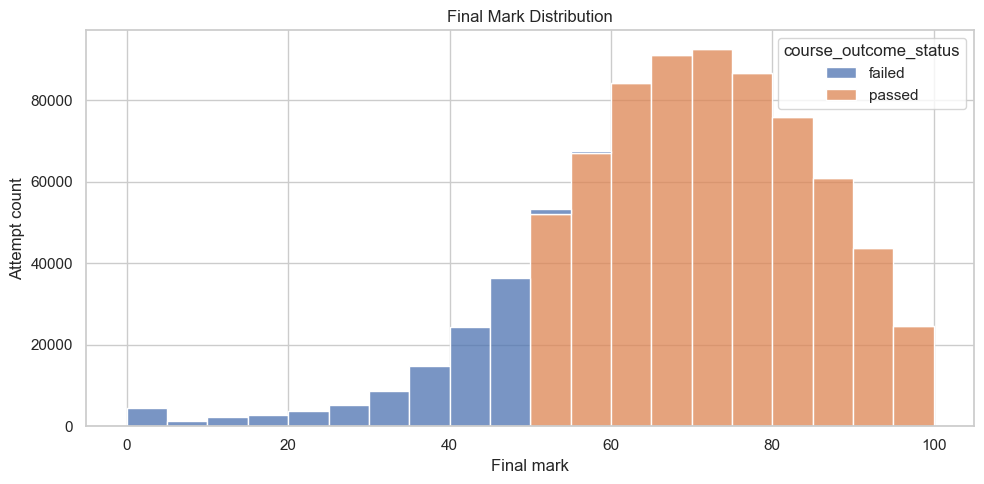

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=clean_student_course_attempts,
    x="final_mark",
    hue="course_outcome_status",
    bins=20,
    multiple="stack",
    ax=ax,
)
ax.set_title("Final Mark Distribution")
ax.set_xlabel("Final mark")
ax.set_ylabel("Attempt count")
plt.tight_layout()
plt.show()

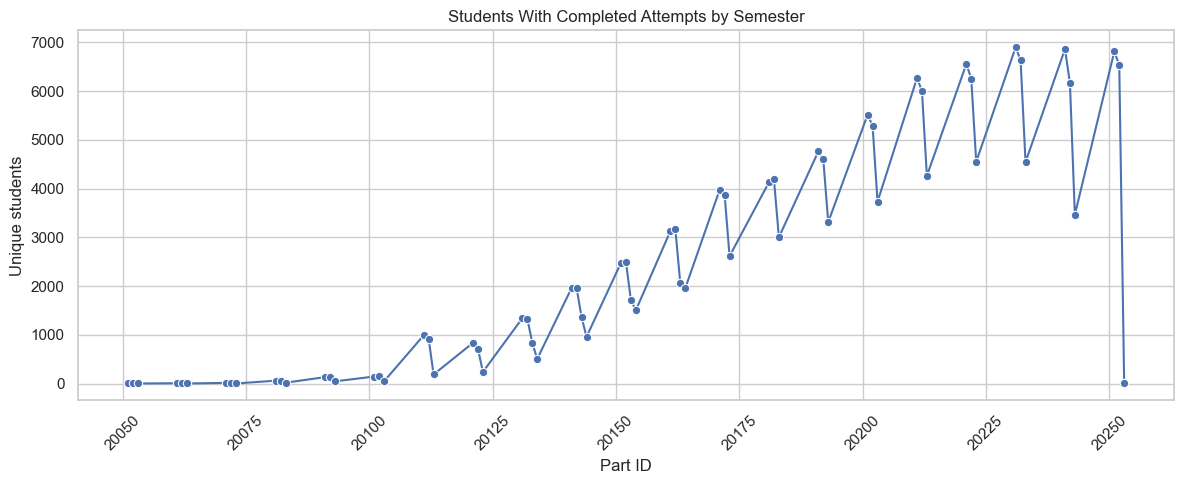

In [31]:
students_by_part = (
    clean_student_course_attempts.groupby("part_id", observed=True)["student_id"]
    .nunique()
    .reset_index(name="student_count")
    .sort_values("part_id")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=students_by_part, x="part_id", y="student_count", marker="o", ax=ax)
ax.set_title("Students With Completed Attempts by Semester")
ax.set_xlabel("Part ID")
ax.set_ylabel("Unique students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

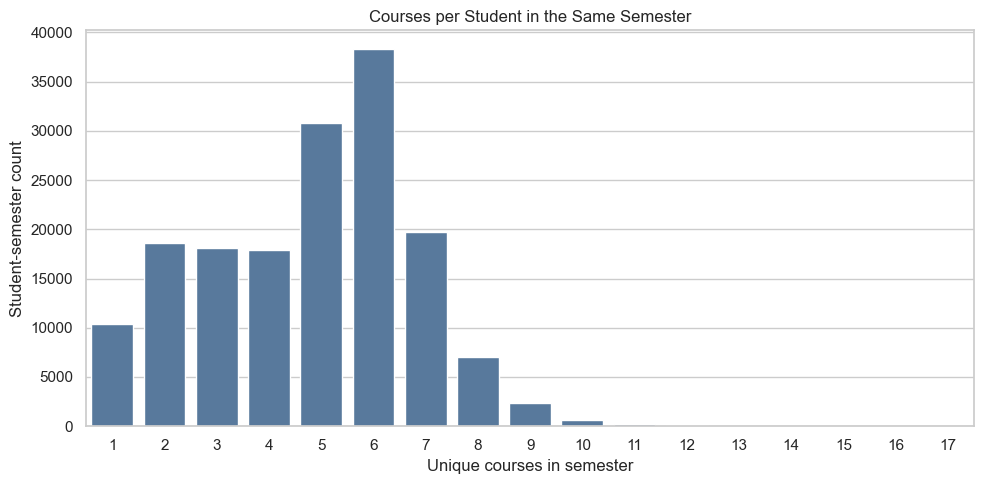

In [32]:
courses_per_student_semester = (
    clean_student_course_attempts.groupby(["student_id", "part_id"], observed=True)["course_id"]
    .nunique()
    .reset_index(name="course_count")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=courses_per_student_semester, x="course_count", color="#4C78A8", ax=ax)
ax.set_title("Courses per Student in the Same Semester")
ax.set_xlabel("Unique courses in semester")
ax.set_ylabel("Student-semester count")
plt.tight_layout()
plt.show()

## Audit Inspection

In [33]:
audit_frames = {
    "audit_removed_inactive": audit_removed_inactive,
    "audit_removed_register_status": audit_removed_register_status,
    "audit_removed_withdrawn": audit_removed_withdrawn,
    "audit_removed_finish_status": audit_removed_finish_status,
    "audit_removed_missing_critical": audit_removed_missing_critical,
    "audit_removed_bad_course_credits": audit_removed_bad_course_credits,
    "audit_removed_bad_final_mark": audit_removed_bad_final_mark,
}

create_audit_summary(audit_frames)

,audit_table,rows,columns
0,audit_removed_inactive,0,20
1,audit_removed_register_status,149814,20
2,audit_removed_withdrawn,40065,20
3,audit_removed_finish_status,40669,20
4,audit_removed_missing_critical,1,20
5,audit_removed_bad_course_credits,2643,20
6,audit_removed_bad_final_mark,0,20


In [34]:
audit_removed_inactive.shape

(0, 20)

In [35]:
audit_removed_inactive.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active


In [36]:
audit_removed_register_status.shape

(149814, 20)

In [37]:
audit_removed_register_status.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
11,430324.111,2141.111,976.111,20132.0,NaN,NaN,NaN,NaN,بيولوجيا جزيئية,D,Y,N,N,C,13.111,وسام خليل القدرو,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
34,431822.111,1972.111,990.111,20132.0,NaN,NaN,NaN,NaN,طفيليات وفطريات,D,Y,N,N,C,13.111,عز الدين عزو رجب,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
75,431993.111,1960.111,965.111,20132.0,NaN,NaN,NaN,NaN,تشريح ونسج,D,Y,N,N,C,13.111,زينب اسامه فران,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
103,432098.111,8427.111,979.111,20132.0,969.111,NaN,0.0,IP,ملازمة 1,D,Y,N,N,C,13.111,امينه عبدالرحمن كوسه,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
129,432197.111,3783.111,658.111,20132.0,NaN,NaN,NaN,NaN,الكيمياء العامة والعضوية,D,Y,N,N,C,2.111,ابراهيم عبد الرزاق الحمود,دكتور في الطب,2.111,4.0,A
158,432265.111,5960.111,246.111,20132.0,NaN,NaN,NaN,NaN,أمراض العين والأذن والأنف والحنجرة,D,Y,N,N,C,16.111,وائل احمد نبيل الرافعي,دكتور في طب الأسنان,3.111,2.0,A
196,432363.111,5944.111,246.111,20132.0,NaN,NaN,NaN,NaN,أمراض العين والأذن والأنف والحنجرة,D,Y,N,N,C,16.111,علي مصطفى مهدي,دكتور في طب الأسنان,3.111,2.0,A
211,432379.111,5894.111,246.111,20132.0,NaN,NaN,NaN,NaN,أمراض العين والأذن والأنف والحنجرة,D,Y,N,N,C,16.111,محمد بهيج الفاعوري,دكتور في طب الأسنان,3.111,2.0,A
212,432380.111,2034.111,967.111,20132.0,NaN,NaN,NaN,NaN,مهارات الحاسوب,D,Y,N,N,C,13.111,عائشه محمد اللحام,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
305,432513.111,8418.111,955.111,20132.0,NaN,NaN,NaN,NaN,اللغة العربية,D,Y,N,N,C,1.111,عبد الرؤوف ياسين شعيب,دكتور في طب الأسنان,3.111,2.0,A


In [38]:
audit_removed_withdrawn.shape

(40065, 20)

In [39]:
audit_removed_withdrawn.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
229,432398.111,8430.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,هيا كمال عبد الحكيم,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1024,434690.111,1946.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,حنين نمر محمد,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1462,439293.111,8426.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,إسراء إسماعيل عبد الله,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1591,439604.111,1900.111,979.111,20132.0,685.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,بيان رشيد القصير,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1603,439731.111,8428.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,نور سهيل حداد,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1692,439903.111,2060.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,فاطمه وفيق ناصر,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1896,440376.111,2007.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,لين حسان معروف,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
1954,440442.111,5753.111,501.111,20132.0,685.111,NaN,0.0,W,الفيزياء 1,R,Y,N,N,C,3.111,محمد إياد محمد ايمن المنديلي,هندسة البرمجيات ونظم المعلومات,5.111,3.0,A
2037,440598.111,1994.111,979.111,20132.0,986.111,0.0,0.0,W,ملازمة 1,R,Y,N,N,C,13.111,مصطفى علاوي رحماوي,الصيدلة و الكيمياء الصيدلية,4.111,1.0,A
2832,448486.111,6197.111,316.111,20132.0,685.111,0.0,0.0,W,تشريح أسنان (2),R,Y,N,N,C,1.111,وسام مفيد الكردي,دكتور في طب الأسنان,3.111,2.0,A


In [40]:
audit_removed_finish_status.shape

(40669, 20)

In [41]:
audit_removed_finish_status.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
198,432365.111,2078.111,965.111,20132.0,686.111,0.0,0.0,Z,تشريح ونسج,R,Y,Y,Y,C,13.111,صهيب عبد اللطيف فريد العش,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A
537,433645.111,3686.111,663.111,20132.0,686.111,0.0,0.0,Z,تاريخ الطب وآدابه,R,Y,Y,Y,C,2.111,شمس الدين نهاد شمسو,دكتور في الطب,2.111,2.0,A
637,433827.111,6178.111,296.111,20132.0,686.111,0.0,0.0,Z,كيمياء حيوية لطب الأسنان (1),R,Y,Y,Y,C,1.111,الاء صبحي النايف,دكتور في طب الأسنان,3.111,3.0,A
639,433829.111,6178.111,962.111,20132.0,686.111,0.0,0.0,Z,اللغة الانكليزية 2,R,Y,Y,Y,C,1.111,الاء صبحي النايف,دكتور في طب الأسنان,3.111,2.0,A
656,433846.111,168.111,176.111,20132.0,973.111,0.0,0.0,Z,ادارة مؤسسات تجارية خارجية,R,Y,Y,Y,C,19.111,بكر بهجت حتروش,إدارة الأعمال,7.111,2.0,A
776,434054.111,6255.111,962.111,20132.0,686.111,0.0,0.0,Z,اللغة الانكليزية 2,R,Y,Y,Y,C,1.111,ليندا محمد سمير عبد الرحمن,دكتور في طب الأسنان,3.111,2.0,A
1408,439208.111,227.111,76.111,20132.0,686.111,0.0,0.0,Z,الإدارة الدولية,R,Y,Y,Y,C,8.111,محمد رأفت بسام محمد,اداره الموارد البشرية,7.111,2.0,A
1722,439960.111,6121.111,962.111,20132.0,686.111,0.0,0.0,Z,اللغة الانكليزية 2,R,Y,Y,Y,C,1.111,فيصل صباح خميس الرفيعي,دكتور في طب الأسنان,3.111,2.0,A
2413,447856.111,1870.111,987.111,20132.0,686.111,0.0,0.0,Z,علم الأدوية 2,R,Y,Y,Y,C,13.111,يوسف رفيق القج,الصيدلة و الكيمياء الصيدلية,4.111,4.0,A
2415,447858.111,1870.111,990.111,20132.0,686.111,0.0,0.0,Z,طفيليات وفطريات,R,Y,Y,Y,C,13.111,يوسف رفيق القج,الصيدلة و الكيمياء الصيدلية,4.111,3.0,A


In [42]:
audit_removed_missing_critical.shape

(1, 20)

In [43]:
audit_removed_missing_critical.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
224574,1095624.111,3432.111,<NA>,<NA>,985.111,0,0.0,F,<NA>,R,Y,Y,Y,C,2.111,محمد يحيى هيثم الخباز,دكتور في الطب,2.111,<NA>,A


In [44]:
audit_removed_bad_course_credits.shape

(2643, 20)

In [45]:
audit_removed_bad_course_credits.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active
278554,1173715.111,12982.111,1162.111,20181,979.111,79,2.75,P,الانكليزية التحضيرية 3,R,Y,Y,Y,C,1.111,مؤمن مازن زيناتي,دكتور في طب الأسنان,3.111,0.0,A
278556,1173717.111,13245.111,1161.111,20181,979.111,75,2.75,P,الانكليزية التحضيرية 2,R,Y,Y,Y,C,13.111,نور ممدوح الخالد,الصيدلة و الكيمياء الصيدلية,4.111,0.0,A
278560,1173722.111,13407.111,1162.111,20181,977.111,85,3.25,P,الانكليزية التحضيرية 3,R,Y,Y,Y,C,2.111,فادي عصام ضاحي,دكتور في الطب,2.111,0.0,A
278563,1173725.111,13310.111,1160.111,20181,985.111,31,0.0,F,الانكليزية التحضيرية 1,R,Y,Y,Y,C,2.111,ولاء سميح خاروف,دكتور في الطب,2.111,0.0,A
278564,1173726.111,13383.111,1160.111,20181,984.111,50,1.5,P,الانكليزية التحضيرية 1,R,Y,Y,Y,C,2.111,تهاني احمد العبد الكحيلات,دكتور في الطب,2.111,0.0,A
278565,1173727.111,12920.111,1162.111,20181,981.111,67,2.25,P,الانكليزية التحضيرية 3,R,Y,Y,Y,C,2.111,شهد عاصم البخاري,دكتور في الطب,2.111,0.0,A
278566,1173728.111,13368.111,1162.111,20181,977.111,88,3.25,P,الانكليزية التحضيرية 3,R,Y,Y,Y,C,2.111,سارة عامر محمد المظلوم,دكتور في الطب,2.111,0.0,A
278591,1173762.111,13201.111,1161.111,20181,976.111,90,3.5,P,الانكليزية التحضيرية 2,R,Y,Y,Y,C,2.111,حسام كمال النقري,دكتور في الطب,2.111,0.0,A
278592,1173763.111,13309.111,1161.111,20181,980.111,71,2.5,P,الانكليزية التحضيرية 2,R,Y,Y,Y,C,2.111,أغيد انس مشوح,دكتور في الطب,2.111,0.0,A
278598,1173773.111,13129.111,1161.111,20181,978.111,81,3.0,P,الانكليزية التحضيرية 2,R,Y,Y,Y,C,2.111,جلال عبد القادر الهبيان,دكتور في الطب,2.111,0.0,A


In [46]:
audit_removed_bad_final_mark.shape

(0, 20)

In [47]:
audit_removed_bad_final_mark.head(20)

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,in_credits,in_gpa,in_agpa,study_mode,degree_id,student_name_sl,degree_name_sl,faculty_id,course_credits,active


This notebook creates the clean completed-attempts core table only.

`clean_student_course_attempts` represents completed course attempts with real pass/fail academic outcomes.

Withdrawn courses are excluded from this clean table and stored in `audit_removed_withdrawn`.

Withdrawn history can be modeled later in a separate feature table if needed.

It does not create:

- `passed_before`
- `failed_before`
- candidate courses
- course difficulty
- model features
- recommendations

In [48]:
clean_student_course_attempts.head()

,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,points,finish_status,course_outcome_status,register_status,in_credits,in_gpa,in_agpa,study_mode,course_credits,course_name_sl,degree_name_sl,attempt_number,attempt_count
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,3.0,P,passed,R,Y,Y,Y,C,2.0,المنطق والتفكير العلمي,هندسة البرمجيات ونظم المعلومات,1,1
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.25,P,passed,R,Y,Y,Y,C,2.0,لغة اجنبية حية (ثانية),هندسة البرمجيات ونظم المعلومات,1,1
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.25,P,passed,R,Y,Y,Y,C,2.0,مدخل الى القانون,هندسة البرمجيات ونظم المعلومات,1,1
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,P,passed,R,Y,Y,Y,C,3.0,الرياضيات المتقطعة,هندسة البرمجيات ونظم المعلومات,1,1
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,2.0,P,passed,R,Y,Y,Y,C,4.0,الجبر الخطي ونظرية المصفوفات,هندسة البرمجيات ونظم المعلومات,1,1


In [49]:
clean_student_course_attempts.shape

(784299, 21)

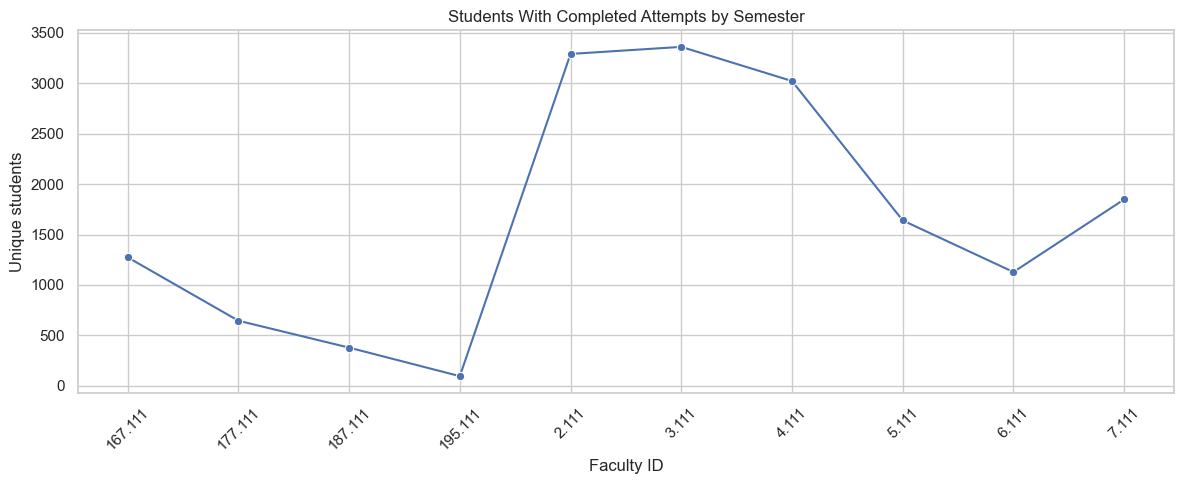

In [50]:
students_by_part = (
    clean_student_course_attempts.groupby("faculty_id", observed=True)["student_id"]
    .nunique()
    .reset_index(name="student_count")
    .sort_values("faculty_id")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=students_by_part, x="faculty_id", y="student_count", marker="o", ax=ax)
ax.set_title("Students With Completed Attempts by Semester")
ax.set_xlabel("Faculty ID")
ax.set_ylabel("Unique students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
clean_student_course_attempts['faculty_id'].value_counts()

faculty_id
3.111      212152
4.111      170621
2.111      159718
5.111       69760
7.111       67392
6.111       44765
167.111     40361
177.111     15477
187.111      3224
195.111       829
Name: count, dtype: int64[pyarrow]

In [52]:
clean_student_course_attempts['course_outcome_status'].value_counts()

course_outcome_status
passed    678645
failed    105654
Name: count, dtype: int64

In [53]:
save_parquet(clean_student_course_attempts, PREPROCESSED_DIR / "V_CRG_STUDENT_COURSE" / "clean_v_crg_student_course.parquet")

WindowsPath('D:/AI/Real projects/Academic_Advisor/data/preprocessed/V_CRG_STUDENT_COURSE/clean_v_crg_student_course.parquet')